# Fine-tune DINOv2 for Object Detection (YOLO-format dataset) on Kaggle

This notebook fine-tunes a **DINOv2** backbone with a **Faster R-CNN** detection head on a
dataset exported in the standard YOLO/Roboflow layout:

```
Football dataset/
    train/
        images/
        labels/
    valid/
        images/
        labels/
    test/
        images/
        labels/
    data.yaml
```

`data.yaml` supplies the class names; each `.txt` file in `labels/` has one line per object:
`class_id x_center y_center width height` (all normalized 0-1), matching the image of the
same filename in `images/`.

## Architecture note
DINOv2 is a Vision Transformer, so it naturally produces a **single-resolution** grid of patch
features (stride 14) rather than the multi-scale feature pyramid a CNN backbone gives you.
This notebook wraps DINOv2's patch tokens into a single feature map and plugs it into
torchvision's Faster R-CNN. This works well for medium/large objects (e.g. players) but will
be weaker on very small/far-away objects (e.g. a distant ball) compared to a purpose-built
multi-scale detector like YOLO. See the notes at the bottom for ways to push accuracy further.

## One-time setup on Kaggle
1. **Add your dataset** (top right → Add Input).
2. **Internet → On** (Settings, right sidebar) — needed to download pretrained DINOv2 weights.
3. **Accelerator → GPU** (Settings).
4. Run all cells top to bottom. You should only need to touch the `CONFIG` cell.


In [1]:
!pip install -q pyyaml pycocotools torchmetrics --upgrade


In [2]:
import os
import time
import random
import warnings
import json
warnings.filterwarnings("ignore")

import yaml
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.ops import MultiScaleRoIAlign
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


Torch: 2.10.0+cu128 | CUDA available: True


In [ ]:
# ============================================================
# CONFIG — the only cell you should normally need to touch
# ============================================================
CONFIG = {
    # Leave as None to auto-detect (looks for data.yaml under /kaggle/input).
    # Or set explicitly, e.g. "/kaggle/input/football-dataset/Football dataset"
    "dataset_root": "/kaggle/input/datasets/oussamamoussa/foot-ball-dataset",

    "model_name": "dinov2_vits14",   # dinov2_vits14 | dinov2_vitb14 | dinov2_vitl14 | dinov2_vitg14
    "img_size": 630,                 # must be divisible by 14 (patch size); 448 also divisible by 32
    "batch_size": 4,                 # detection is memory-hungry — try 8 if you have headroom, drop to 2 on OOM
    "epochs": 20,                     # with 46.5k images, fewer epochs go a long way — raise if still improving
    "head_lr": 1e-3,                  # lr for RPN + ROI heads (the new, untrained parts)
    "backbone_lr": 1e-5,              # lr for any trainable DINOv2 layers (see backbone_train_mode)
    # How much of DINOv2 to train:
    #   "frozen"  -> backbone fully frozen, only the detection head trains (fastest, least memory)
    #   "partial" -> only the last `unfreeze_last_n_blocks` transformer blocks (+ final norm) train
    #   "full"    -> the entire backbone trains (needs the most data/memory)
    "backbone_train_mode": "partial",
    "unfreeze_last_n_blocks": 4,       # only used when backbone_train_mode == "partial"
    "score_threshold": 0.5,          # min confidence to keep a prediction when visualizing/inferring
    "num_workers": 2,
    "seed": 42,
    "output_dir": "/kaggle/working",
    "early_stopping_patience": 5,

    # Set this to a previous run's checkpoint path to continue training across Kaggle sessions.
    # Tip: don't guess this path from the dataset's web URL — after adding it as an input, run
    #   !find /kaggle/input -iname "*.pt"
    # in a cell to get the real mounted path. If this path is wrong or missing, the training
    # loop automatically searches /kaggle/input for last_checkpoint.pt as a fallback anyway.
    # Leave as None to start fresh.
    "resume_from": "",

    # Only used by Option A (multi-GPU / DDP training) below — set to how many GPUs you actually
    # have (e.g. 2 for Kaggle's "GPU T4 x2"). Ignored entirely if you use Option B (single-GPU).
    "num_gpus": 2,

    # Countermeasures for the overfitting + rare-class (ball) issues seen in evaluation:
    "use_augmentation": True,           # random horizontal flip on training images (val unaffected)
    "use_class_balanced_sampler": True, # oversample images containing rarer classes each epoch
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
assert CONFIG["img_size"] % 14 == 0, "img_size must be a multiple of 14 (DINOv2 patch size)"


In [4]:
# ============================================================
# Reproducibility + device
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — training will be extremely slow (likely hours per epoch "
          "even to look 'stuck'). Check Settings -> Accelerator -> GPU is turned on, then "
          "Factory Reset / restart the session so it actually takes effect.")


Using device: cuda
GPU: Tesla T4


In [5]:
# ============================================================
# Auto-detect the dataset (find data.yaml, parse class names, locate split folders)
# ============================================================
def find_data_yaml(root="/kaggle/input"):
    for dirpath, dirnames, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower() == "data.yaml":
                return os.path.join(dirpath, fn)
    return None

if CONFIG["dataset_root"] is None:
    yaml_path = find_data_yaml()
    if yaml_path is None:
        raise RuntimeError(
            "Could not find data.yaml under /kaggle/input. Set CONFIG['dataset_root'] "
            "manually to the folder that directly contains train/, valid/, test/, data.yaml."
        )
    dataset_root = os.path.dirname(yaml_path)
else:
    dataset_root = CONFIG["dataset_root"]
    yaml_path = os.path.join(dataset_root, "data.yaml")

print("Dataset root:", dataset_root)

with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg.get("names")
if isinstance(class_names, dict):
    class_names = [class_names[k] for k in sorted(class_names.keys())]
num_classes = len(class_names)
print(f"Classes ({num_classes}):", class_names)

def resolve_split_dir(root, candidate_names):
    for n in candidate_names:
        p = os.path.join(root, n)
        if os.path.isdir(p):
            return p
    return None

def get_images_labels_dirs(split_root):
    if split_root is None:
        return None, None
    images_dir = os.path.join(split_root, "images")
    labels_dir = os.path.join(split_root, "labels")
    if os.path.isdir(images_dir) and os.path.isdir(labels_dir):
        return images_dir, labels_dir
    raise RuntimeError(
        f"Expected '{split_root}/images' and '{split_root}/labels' but didn't find both. "
        "Check your dataset's folder structure."
    )

train_root = resolve_split_dir(dataset_root, ["train"])
valid_root = resolve_split_dir(dataset_root, ["valid", "val", "validation"])
test_root = resolve_split_dir(dataset_root, ["test"])

train_images_dir, train_labels_dir = get_images_labels_dirs(train_root)
valid_images_dir, valid_labels_dir = get_images_labels_dirs(valid_root)
test_images_dir, test_labels_dir = get_images_labels_dirs(test_root)

print("train:", train_images_dir)
print("valid:", valid_images_dir)
print("test: ", test_images_dir)


Dataset root: /kaggle/input/datasets/oussamamoussa/foot-ball-dataset
Classes (4): ['ball', 'goalkeeper', 'player', 'referee']
train: /kaggle/input/datasets/oussamamoussa/foot-ball-dataset/train/images
valid: /kaggle/input/datasets/oussamamoussa/foot-ball-dataset/valid/images
test:  /kaggle/input/datasets/oussamamoussa/foot-ball-dataset/test/images


In [6]:
# ============================================================
# Shared checkpoint paths + config export.
# Run this regardless of which training path you pick below (Option A: multi-GPU / DDP,
# or Option B: single-GPU) — later cells (plotting, evaluation) rely on it either way.
# The JSON export is what lets the multi-GPU script (a separate process) see your dataset
# paths and CONFIG without duplicating the auto-detection logic above.
# ============================================================
ckpt_path = os.path.join(CONFIG["output_dir"], "best_detector.pt")
last_ckpt_path = os.path.join(CONFIG["output_dir"], "last_checkpoint.pt")

run_config = {
    "config": CONFIG,
    "paths": {
        "train_images_dir": train_images_dir,
        "train_labels_dir": train_labels_dir,
        "valid_images_dir": valid_images_dir,
        "valid_labels_dir": valid_labels_dir,
        "class_names": class_names,
    },
}
run_config_path = os.path.join(CONFIG["output_dir"], "run_config.json")
with open(run_config_path, "w") as f:
    json.dump(run_config, f, indent=2)
print("Wrote", run_config_path)


Wrote /kaggle/working/run_config.json


In [7]:
# ============================================================
# Per-class instance counts — sanity-check for class imbalance before training.
# Sports datasets are often heavily skewed (e.g. many 'player' boxes, few 'ball' boxes),
# which can make a rare class look like it "isn't learning" when it's really just underrepresented.
# ============================================================
from collections import Counter

def count_instances_per_class(labels_dir, class_names):
    counts = Counter()
    for fname in os.listdir(labels_dir):
        if not fname.endswith(".txt"):
            continue
        with open(os.path.join(labels_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(float(parts[0]))
                counts[class_names[cls_id]] += 1
    return counts

train_counts = count_instances_per_class(train_labels_dir, class_names)
print("Instance counts per class (train set):")
for name in class_names:
    print(f"  {name}: {train_counts.get(name, 0)}")


Instance counts per class (train set):
  ball: 34412
  goalkeeper: 21546
  player: 742370
  referee: 70450


In [8]:
# ============================================================
# Dataset — parses YOLO-format .txt labels into torchvision detection targets.
# Includes optional random horizontal flip (train only) and a class-balanced sampler,
# both aimed at the overfitting + rare-class (ball) problems seen in evaluation.
# ============================================================
class YoloDetectionDataset(torch.utils.data.Dataset):
    IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    def __init__(self, images_dir, labels_dir, augment=False):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.augment = augment
        self.image_files = sorted(
            f for f in os.listdir(images_dir) if f.lower().endswith(self.IMG_EXTS)
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        fname = self.image_files[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        w, h = img.size

        label_path = os.path.join(self.labels_dir, os.path.splitext(fname)[0] + ".txt")
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(float(parts[0]))
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1 = max(0.0, (xc - bw / 2) * w)
                    y1 = max(0.0, (yc - bh / 2) * h)
                    x2 = min(float(w), (xc + bw / 2) * w)
                    y2 = min(float(h), (yc + bh / 2) * h)
                    if x2 <= x1 or y2 <= y1:
                        continue
                    boxes.append([x1, y1, x2, y2])
                    labels.append(cls_id + 1)  # +1: torchvision reserves label 0 for background

        # Random horizontal flip — training only. Football footage is left/right symmetric
        # (no meaning is lost flipping a pitch), so this is a safe, cheap way to effectively
        # double the visual variety of every image the model sees.
        if self.augment and random.random() < 0.5:
            img = TF.hflip(img)
            for box in boxes:
                x1, x2 = box[0], box[2]
                box[0], box[2] = w - x2, w - x1

        # NOTE: no manual resizing here — we hand raw-size images to Faster R-CNN and let its
        # internal transform resize both the image AND boxes together (see model build cell).
        image_tensor = TF.to_tensor(img)  # float32, 0-1 range, shape (3, H, W)

        if boxes:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)
            area = (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1])
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }
        return image_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


def compute_class_balanced_weights(images_dir, labels_dir, image_files):
    """One weight per image: images containing rarer classes get sampled more often.
    Background-only images (no label file / empty) get a neutral baseline weight."""
    class_counts = Counter()
    image_classes = []
    for fname in image_files:
        label_path = os.path.join(labels_dir, os.path.splitext(fname)[0] + ".txt")
        present = set()
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(float(parts[0]))
                    present.add(cls_id)
                    class_counts[cls_id] += 1
        image_classes.append(present)

    if not class_counts:
        return [1.0] * len(image_files)

    max_count = max(class_counts.values())
    inv_freq = {cid: max_count / count for cid, count in class_counts.items()}

    weights = []
    for present in image_classes:
        weights.append(max((inv_freq[c] for c in present), default=1.0))
    return weights


train_ds = YoloDetectionDataset(train_images_dir, train_labels_dir, augment=CONFIG["use_augmentation"])
val_ds = YoloDetectionDataset(valid_images_dir, valid_labels_dir, augment=False) if valid_images_dir else None
test_ds = YoloDetectionDataset(test_images_dir, test_labels_dir, augment=False) if test_images_dir else None

if CONFIG["use_class_balanced_sampler"]:
    train_weights = compute_class_balanced_weights(train_images_dir, train_labels_dir, train_ds.image_files)
    train_sampler = torch.utils.data.WeightedRandomSampler(
        weights=train_weights, num_samples=len(train_weights), replacement=True
    )
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=train_sampler,
                               num_workers=CONFIG["num_workers"], collate_fn=collate_fn)
    print("Using class-balanced sampling (images with rarer classes are oversampled).")
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], collate_fn=collate_fn)

val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], collate_fn=collate_fn) if val_ds else None
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=CONFIG["num_workers"], collate_fn=collate_fn) if test_ds else None

print(f"Train images: {len(train_ds)}")
print(f"Val images:   {len(val_ds) if val_ds else 0}")
print(f"Test images:  {len(test_ds) if test_ds else 0}")


Using class-balanced sampling (images with rarer classes are oversampled).
Train images: 46511
Val images:   4757
Test images:  2177


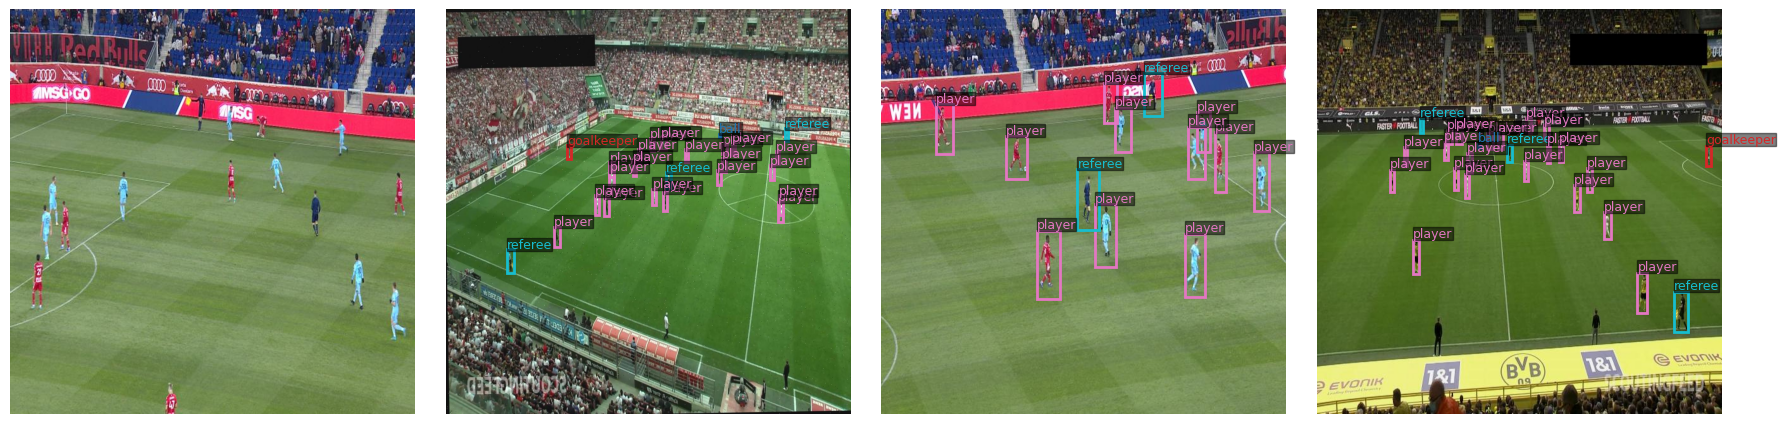

In [9]:
# ============================================================
# Sanity check — draw ground-truth boxes on a few training images, color-coded by class.
# ALWAYS look at this before training: it catches label-parsing bugs and class mix-ups early.
# ============================================================
CLASS_COLORS = plt.cm.get_cmap("tab10", max(len(class_names), 1))

def show_sample(dataset, idx, ax):
    img, target = dataset[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        color = CLASS_COLORS(label - 1)
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         fill=False, edgecolor=color, linewidth=2))
        ax.text(x1, max(0, y1 - 4), class_names[label - 1], color=color, fontsize=9,
                 bbox=dict(facecolor="black", alpha=0.5, pad=0))
    ax.axis("off")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sample_idxs = random.sample(range(len(train_ds)), min(4, len(train_ds)))
for ax, idx in zip(axes, sample_idxs):
    show_sample(train_ds, idx, ax)
plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# DINOv2 backbone wrapped as a single-level feature map for Faster R-CNN
# ============================================================
EMBED_DIMS = {
    "dinov2_vits14": 384,
    "dinov2_vitb14": 768,
    "dinov2_vitl14": 1024,
    "dinov2_vitg14": 1536,
}
PATCH_SIZE = 14

class DinoV2Backbone(nn.Module):
    def __init__(self, model_name, train_mode="frozen", unfreeze_last_n_blocks=0):
        super().__init__()
        self.model = torch.hub.load("facebookresearch/dinov2", model_name)
        self.embed_dim = EMBED_DIMS[model_name]
        self.out_channels = self.embed_dim  # required attribute for torchvision detection models
        self.train_mode = train_mode

        if train_mode == "frozen":
            for p in self.model.parameters():
                p.requires_grad = False
            self.fully_frozen = True

        elif train_mode == "partial":
            # Freeze everything, then unfreeze just the last N transformer blocks + final norm.
            # Lower blocks encode general-purpose visual features that transfer well as-is;
            # the last few blocks are where task-specific adaptation matters most.
            for p in self.model.parameters():
                p.requires_grad = False
            total_blocks = len(self.model.blocks)
            n = min(unfreeze_last_n_blocks, total_blocks)
            for block in self.model.blocks[total_blocks - n:]:
                for p in block.parameters():
                    p.requires_grad = True
            if hasattr(self.model, "norm"):
                for p in self.model.norm.parameters():
                    p.requires_grad = True
            self.fully_frozen = False
            print(f"DINOv2: unfroze last {n}/{total_blocks} transformer blocks (+ final norm).")

        elif train_mode == "full":
            for p in self.model.parameters():
                p.requires_grad = True
            self.fully_frozen = False

        else:
            raise ValueError(f"Unknown backbone_train_mode: {train_mode!r}")

    def forward(self, x):
        b, c, h, w = x.shape
        ctx = torch.no_grad() if self.fully_frozen else torch.enable_grad()
        with ctx:
            feats = self.model.forward_features(x)
        patch_tokens = feats["x_norm_patchtokens"]  # (B, N, embed_dim)
        gh, gw = h // PATCH_SIZE, w // PATCH_SIZE
        feat_map = patch_tokens.permute(0, 2, 1).reshape(b, self.embed_dim, gh, gw)
        return {"0": feat_map}  # single-level feature map, keyed for MultiScaleRoIAlign

    def train(self, mode=True):
        super().train(mode)
        if self.fully_frozen:
            self.model.eval()
        return self


In [11]:
# ============================================================
# Build the Faster R-CNN model on top of the DINOv2 backbone
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

backbone = DinoV2Backbone(
    CONFIG["model_name"],
    train_mode=CONFIG["backbone_train_mode"],
    unfreeze_last_n_blocks=CONFIG["unfreeze_last_n_blocks"],
)

anchor_generator = AnchorGenerator(
    sizes=((16, 32, 64, 128, 256),),
    aspect_ratios=((0.5, 1.0, 2.0),),
)
roi_pooler = MultiScaleRoIAlign(featmap_names=["0"], output_size=7, sampling_ratio=2)

model = FasterRCNN(
    backbone,
    num_classes=num_classes + 1,  # +1 for background
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler,
    min_size=CONFIG["img_size"],
    max_size=CONFIG["img_size"],
    image_mean=IMAGENET_MEAN,
    image_std=IMAGENET_STD,
)

# Override the internal resize/pad transform: default padding rounds up to a multiple of 32,
# which can break DINOv2's 14x14 patch grid. Force padding to a multiple of 14 instead.
model.transform = GeneralizedRCNNTransform(
    min_size=CONFIG["img_size"], max_size=CONFIG["img_size"],
    image_mean=IMAGENET_MEAN, image_std=IMAGENET_STD,
    size_divisible=PATCH_SIZE,
)

model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 153MB/s]


DINOv2: unfroze last 6/12 transformer blocks (+ final norm).
Trainable params: 32,352,356 / 43,756,772


## Choose your training path

Run **one** of the two options below, not both.

- **Option A — Multi-GPU (DDP)**: use this if you have 2+ GPUs (e.g. Kaggle's "GPU T4 x2").
  Training runs as a separate script launched with `torchrun`, one process per GPU, using real
  `DistributedDataParallel` — not the broken `nn.DataParallel` shortcut, which doesn't work
  correctly with detection models (they take lists of variable-sized images, not a single
  batched tensor `DataParallel` can split).
- **Option B — Single-GPU**: what you were already running. Simpler, fully inline in the
  notebook, but only uses one of your two GPUs.

Either way, run every cell **above** this one first (through "Trainable params" above) — those
define `model` and export `run_config.json`, both needed regardless of which option you pick.
After training finishes (either option), skip straight to "Training curves" further down.


### Option A: Multi-GPU (DDP) training

This writes a standalone training script to disk, then launches it with `torchrun` — one
process per GPU. It reads `run_config.json` (written above) for your dataset paths and
hyperparameters, so no arguments to edit here.


In [12]:
%%writefile train_ddp.py
# Standalone multi-GPU training script, launched via torchrun (see the next cell).
# Runs as separate OS processes (one per GPU) — it does NOT share memory/variables with the
# notebook kernel, which is why the dataset/backbone/model logic is duplicated here rather than
# imported from earlier cells. It reads run_config.json for dataset paths + CONFIG instead.

import os
import json
import time
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
import torchvision.transforms.functional as TF
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.ops import MultiScaleRoIAlign
from PIL import Image

PATCH_SIZE = 14
EMBED_DIMS = {
    "dinov2_vits14": 384,
    "dinov2_vitb14": 768,
    "dinov2_vitl14": 1024,
    "dinov2_vitg14": 1536,
}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class YoloDetectionDataset(torch.utils.data.Dataset):
    IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    def __init__(self, images_dir, labels_dir, augment=False):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.augment = augment
        self.image_files = sorted(
            f for f in os.listdir(images_dir) if f.lower().endswith(self.IMG_EXTS)
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        fname = self.image_files[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        w, h = img.size
        label_path = os.path.join(self.labels_dir, os.path.splitext(fname)[0] + ".txt")
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(float(parts[0]))
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1 = max(0.0, (xc - bw / 2) * w)
                    y1 = max(0.0, (yc - bh / 2) * h)
                    x2 = min(float(w), (xc + bw / 2) * w)
                    y2 = min(float(h), (yc + bh / 2) * h)
                    if x2 <= x1 or y2 <= y1:
                        continue
                    boxes.append([x1, y1, x2, y2])
                    labels.append(cls_id + 1)  # +1: label 0 reserved for background
        if self.augment and random.random() < 0.5:
            img = TF.hflip(img)
            for box in boxes:
                x1, x2 = box[0], box[2]
                box[0], box[2] = w - x2, w - x1
        image_tensor = TF.to_tensor(img)
        if boxes:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)
            area = (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1])
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        return image_tensor, {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }


def compute_class_balanced_weights(labels_dir, image_files):
    class_counts = Counter()
    image_classes = []
    for fname in image_files:
        label_path = os.path.join(labels_dir, os.path.splitext(fname)[0] + ".txt")
        present = set()
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(float(parts[0]))
                    present.add(cls_id)
                    class_counts[cls_id] += 1
        image_classes.append(present)
    if not class_counts:
        return [1.0] * len(image_files)
    max_count = max(class_counts.values())
    inv_freq = {cid: max_count / count for cid, count in class_counts.items()}
    return [max((inv_freq[c] for c in present), default=1.0) for present in image_classes]


def collate_fn(batch):
    return tuple(zip(*batch))


class DinoV2Backbone(nn.Module):
    def __init__(self, model_name, train_mode="frozen", unfreeze_last_n_blocks=0):
        super().__init__()
        self.model = torch.hub.load("facebookresearch/dinov2", model_name)
        self.embed_dim = EMBED_DIMS[model_name]
        self.out_channels = self.embed_dim
        if train_mode == "frozen":
            for p in self.model.parameters():
                p.requires_grad = False
            self.fully_frozen = True
        elif train_mode == "partial":
            for p in self.model.parameters():
                p.requires_grad = False
            total_blocks = len(self.model.blocks)
            n = min(unfreeze_last_n_blocks, total_blocks)
            for block in self.model.blocks[total_blocks - n:]:
                for p in block.parameters():
                    p.requires_grad = True
            if hasattr(self.model, "norm"):
                for p in self.model.norm.parameters():
                    p.requires_grad = True
            self.fully_frozen = False
        elif train_mode == "full":
            for p in self.model.parameters():
                p.requires_grad = True
            self.fully_frozen = False
        else:
            raise ValueError(f"Unknown backbone_train_mode: {train_mode!r}")

    def forward(self, x):
        b, c, h, w = x.shape
        ctx = torch.no_grad() if self.fully_frozen else torch.enable_grad()
        with ctx:
            feats = self.model.forward_features(x)
        patch_tokens = feats["x_norm_patchtokens"]
        gh, gw = h // PATCH_SIZE, w // PATCH_SIZE
        feat_map = patch_tokens.permute(0, 2, 1).reshape(b, self.embed_dim, gh, gw)
        return {"0": feat_map}

    def train(self, mode=True):
        super().train(mode)
        if self.fully_frozen:
            self.model.eval()
        return self


def build_model(config, num_classes):
    backbone = DinoV2Backbone(
        config["model_name"],
        train_mode=config["backbone_train_mode"],
        unfreeze_last_n_blocks=config["unfreeze_last_n_blocks"],
    )
    anchor_generator = AnchorGenerator(sizes=((16, 32, 64, 128, 256),), aspect_ratios=((0.5, 1.0, 2.0),))
    roi_pooler = MultiScaleRoIAlign(featmap_names=["0"], output_size=7, sampling_ratio=2)
    model = FasterRCNN(
        backbone,
        num_classes=num_classes + 1,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=config["img_size"],
        max_size=config["img_size"],
        image_mean=IMAGENET_MEAN,
        image_std=IMAGENET_STD,
    )
    model.transform = GeneralizedRCNNTransform(
        min_size=config["img_size"], max_size=config["img_size"],
        image_mean=IMAGENET_MEAN, image_std=IMAGENET_STD,
        size_divisible=PATCH_SIZE,
    )
    return model


def main():
    local_rank = int(os.environ["LOCAL_RANK"])
    dist.init_process_group(backend="nccl")
    torch.cuda.set_device(local_rank)
    device = torch.device("cuda", local_rank)
    rank = dist.get_rank()
    world_size = dist.get_world_size()

    with open("run_config.json") as f:
        run_cfg = json.load(f)
    config = run_cfg["config"]
    paths = run_cfg["paths"]
    class_names = paths["class_names"]
    num_classes = len(class_names)

    random.seed(config["seed"] + rank)
    np.random.seed(config["seed"] + rank)
    torch.manual_seed(config["seed"])
    torch.cuda.manual_seed_all(config["seed"])

    train_ds = YoloDetectionDataset(paths["train_images_dir"], paths["train_labels_dir"],
                                     augment=config["use_augmentation"])
    val_ds = None
    if paths.get("valid_images_dir"):
        val_ds = YoloDetectionDataset(paths["valid_images_dir"], paths["valid_labels_dir"], augment=False)

    if config["use_class_balanced_sampler"]:
        # torch's built-in DistributedSampler has no weights argument, so this is a small custom
        # sampler: each epoch, draw a weighted sample (with replacement) across the WHOLE dataset,
        # then give every rank a different, non-overlapping slice of it — same idea as
        # DistributedSampler, but weighted.
        class DistributedWeightedSampler(torch.utils.data.Sampler):
            def __init__(self, weights, num_replicas, rank, seed=0):
                self.weights = torch.as_tensor(weights, dtype=torch.double)
                self.num_replicas = num_replicas
                self.rank = rank
                self.seed = seed
                self.epoch = 0
                self.num_samples = len(weights) // num_replicas

            def set_epoch(self, epoch):
                self.epoch = epoch

            def __iter__(self):
                g = torch.Generator()
                g.manual_seed(self.seed + self.epoch)
                total = self.num_samples * self.num_replicas
                indices = torch.multinomial(self.weights, total, replacement=True, generator=g)
                return iter(indices[self.rank:total:self.num_replicas].tolist())

            def __len__(self):
                return self.num_samples

        train_weights = compute_class_balanced_weights(paths["train_labels_dir"], train_ds.image_files)
        train_sampler = DistributedWeightedSampler(train_weights, num_replicas=world_size, rank=rank,
                                                     seed=config["seed"])
        if rank == 0:
            print("Using class-balanced sampling (images with rarer classes are oversampled).", flush=True)
    else:
        train_sampler = DistributedSampler(train_ds, num_replicas=world_size, rank=rank,
                                            shuffle=True, seed=config["seed"])
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], sampler=train_sampler,
                               num_workers=config["num_workers"], collate_fn=collate_fn)

    val_loader = None
    if val_ds is not None:
        val_sampler = DistributedSampler(val_ds, num_replicas=world_size, rank=rank, shuffle=False)
        val_loader = DataLoader(val_ds, batch_size=config["batch_size"], sampler=val_sampler,
                                 num_workers=config["num_workers"], collate_fn=collate_fn)

    model = build_model(config, num_classes).to(device)
    ddp_model = DDP(model, device_ids=[local_rank])

    head_params = [p for n, p in ddp_model.named_parameters() if "backbone." not in n and p.requires_grad]
    backbone_params = [p for n, p in ddp_model.named_parameters() if "backbone." in n and p.requires_grad]
    param_groups = [{"params": head_params, "lr": config["head_lr"]}]
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": config["backbone_lr"]})
    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    scaler = torch.cuda.amp.GradScaler()

    ckpt_path = os.path.join(config["output_dir"], "best_detector.pt")
    last_ckpt_path = os.path.join(config["output_dir"], "last_checkpoint.pt")

    start_epoch, best_val_loss, patience_counter = 0, float("inf"), 0
    history = {"train_loss": [], "val_loss": []}

    resume_path = config.get("resume_from")
    if resume_path and os.path.isfile(resume_path):
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        history = ckpt.get("history", history)
        best_val_loss = ckpt.get("best_val_loss", best_val_loss)
        patience_counter = 0  # reset: don't let an already-hit early-stopping limit re-trigger immediately
        if rank == 0:
            print(f"Resumed from {resume_path} at epoch {start_epoch} (patience counter reset)", flush=True)

    for epoch in range(start_epoch, config["epochs"]):
        t0 = time.time()
        train_sampler.set_epoch(epoch)
        ddp_model.train()
        total_loss, n = 0.0, 0
        for i, (images, targets) in enumerate(train_loader):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            with torch.cuda.amp.autocast():
                loss_dict = ddp_model(images, targets)
                loss = sum(loss_dict.values())
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * len(images)
            n += len(images)
            if rank == 0 and (i + 1) % 50 == 0:
                print(f"Epoch {epoch+1} | batch {i+1}/{len(train_loader)} "
                      f"| running loss {total_loss/n:.4f}", flush=True)

        loss_tensor = torch.tensor([total_loss, float(n)], device=device)
        dist.all_reduce(loss_tensor, op=dist.ReduceOp.SUM)
        train_loss = (loss_tensor[0] / loss_tensor[1]).item()

        val_loss = None
        if val_loader is not None:
            ddp_model.train()  # stays in train() mode so forward() still returns losses; no backward call below
            v_total, v_n = 0.0, 0
            with torch.no_grad():
                for images, targets in val_loader:
                    images = [img.to(device) for img in images]
                    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                    loss_dict = ddp_model(images, targets)
                    loss = sum(loss_dict.values())
                    v_total += loss.item() * len(images)
                    v_n += len(images)
            v_tensor = torch.tensor([v_total, float(v_n)], device=device)
            dist.all_reduce(v_tensor, op=dist.ReduceOp.SUM)
            val_loss = (v_tensor[0] / v_tensor[1]).item()

        scheduler.step()

        if rank == 0:
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            msg = f"Epoch {epoch+1}/{config['epochs']} | train_loss {train_loss:.4f}"
            if val_loss is not None:
                msg += f" | val_loss {val_loss:.4f}"
            msg += f" | {time.time()-t0:.1f}s"
            print(msg, flush=True)

            tracked_loss = val_loss if val_loss is not None else train_loss
            if tracked_loss < best_val_loss:
                best_val_loss = tracked_loss
                patience_counter = 0
                torch.save({
                    "model_state_dict": model.state_dict(),  # unwrapped — no "module." prefix
                    "class_names": class_names,
                    "config": config,
                }, ckpt_path, _use_new_zipfile_serialization=False)
                print(f"  -> new best loss {best_val_loss:.4f}, checkpoint saved.", flush=True)
            else:
                patience_counter += 1

            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "epoch": epoch,
                "history": history,
                "best_val_loss": best_val_loss,
                "patience_counter": patience_counter,
                "class_names": class_names,
                "config": config,
            }, last_ckpt_path, _use_new_zipfile_serialization=False)

        should_stop = rank == 0 and patience_counter >= config["early_stopping_patience"]
        stop_flag = torch.tensor([1 if should_stop else 0], device=device)
        dist.broadcast(stop_flag, src=0)
        if stop_flag.item() == 1:
            if rank == 0:
                print("Early stopping triggered.", flush=True)
            break

    dist.destroy_process_group()


if __name__ == "__main__":
    main()


Writing train_ddp.py


In [13]:
# Launch training across both GPUs. --standalone handles the coordination automatically
# (no manual rendezvous address/port setup needed for a single machine).
!torchrun --standalone --nproc_per_node={CONFIG['num_gpus']} train_ddp.py


W0920 01:59:15.792000 66 torch/distributed/run.py:852] 
W0920 01:59:15.792000 66 torch/distributed/run.py:852] *****************************************
W0920 01:59:15.792000 66 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0920 01:59:15.792000 66 torch/distributed/run.py:852] *****************************************
[W920 01:59:15.638776368 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W920 01:59:18.389367129 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W920 01:59:18.393110193 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
Using class-balanced sampling (images with rarer classes are oversampled).
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using c

### Option B: Single-GPU training

Skip this whole section if you already ran Option A above.


In [14]:
# ============================================================
# Final evaluation: COCO-style detection metrics on the validation set
# ============================================================
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)

if val_loader is not None:
    t0 = time.time()
    n_images = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            preds = model(images)
            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            metric.update(preds_cpu, targets)
            n_images += len(images)
    inference_time = time.time() - t0

    results = metric.compute()

    print("Overall (all classes, all object sizes):")
    print(f"  mAP@[0.5:0.95]: {results['map'].item():.4f}")
    print(f"  mAP@0.5:        {results['map_50'].item():.4f}")
    print(f"  mAP@0.75:       {results['map_75'].item():.4f}")
    print(f"  mAR@100 dets:   {results['mar_100'].item():.4f}  "
          f"(mAR@1: {results['mar_1'].item():.4f}, mAR@10: {results['mar_10'].item():.4f})")

    print("\nBy object size (COCO convention: small <32x32px, medium <96x96px, large otherwise)")
    print("  -- relevant here since a ball and a player are very different sizes:")
    for size in ("small", "medium", "large"):
        val = results[f"map_{size}"].item()
        flag = "  (no objects of this size in val set)" if val < 0 else ""
        print(f"  mAP ({size}): {val:.4f}{flag}")

    print("\nPer-class breakdown (mAP@[0.5:0.95] and mAR@100):")
    ap_by_class = dict(zip(results["classes"].tolist(), results["map_per_class"].tolist()))
    ar_by_class = dict(zip(results["classes"].tolist(), results["mar_100_per_class"].tolist()))
    for class_id in sorted(ap_by_class):
        name = class_names[class_id - 1]
        print(f"  {name}: mAP {ap_by_class[class_id]:.4f} | mAR {ar_by_class[class_id]:.4f}")

    print(f"\nInference speed: {n_images/inference_time:.1f} images/sec "
          f"({inference_time/n_images*1000:.1f} ms/image) on this GPU, batch_size={CONFIG['batch_size']}")
else:
    print("No validation set found — skipping evaluation.")


Overall (all classes, all object sizes):
  mAP@[0.5:0.95]: 0.1986
  mAP@0.5:        0.4363
  mAP@0.75:       0.1481
  mAR@100 dets:   0.3322  (mAR@1: 0.1503, mAR@10: 0.2766)

By object size (COCO convention: small <32x32px, medium <96x96px, large otherwise)
  -- relevant here since a ball and a player are very different sizes:
  mAP (small): 0.1776
  mAP (medium): 0.2836
  mAP (large): 0.4530

Per-class breakdown (mAP@[0.5:0.95] and mAR@100):
  ball: mAP 0.0590 | mAR 0.1448
  goalkeeper: mAP 0.1451 | mAR 0.2983
  player: mAP 0.4470 | mAR 0.5552
  referee: mAP 0.1435 | mAR 0.3306

Inference speed: 13.0 images/sec (76.7 ms/image) on this GPU, batch_size=4


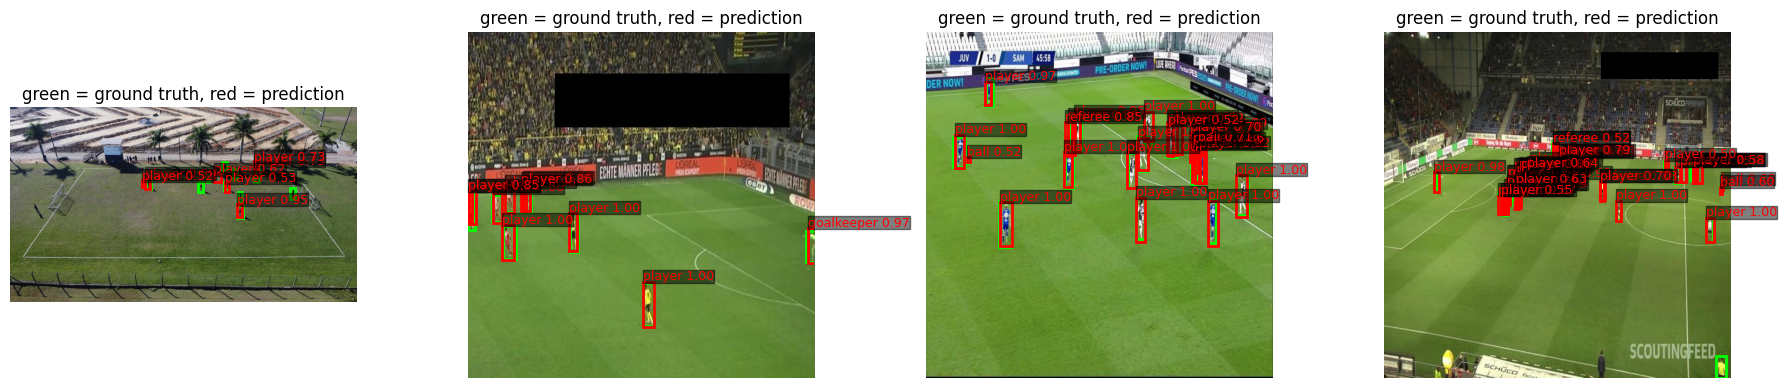

In [15]:
# ============================================================
# Visualize predictions vs ground truth on a few validation images
# ============================================================
def show_predictions(dataset, idx, ax, score_threshold=CONFIG["score_threshold"]):
    img, target = dataset[idx]
    model.eval()
    with torch.no_grad():
        pred = model([img.to(device)])[0]

    ax.imshow(img.permute(1, 2, 0).numpy())
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         fill=False, edgecolor="lime", linewidth=2))
    for box, label, score in zip(pred["boxes"].cpu(), pred["labels"].cpu(), pred["scores"].cpu()):
        if score < score_threshold:
            continue
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         fill=False, edgecolor="red", linewidth=2))
        ax.text(x1, max(0, y1 - 4), f"{class_names[label-1]} {score:.2f}",
                 color="red", fontsize=9, bbox=dict(facecolor="black", alpha=0.5, pad=0))
    ax.set_title("green = ground truth, red = prediction")
    ax.axis("off")

if val_ds is not None:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    sample_idxs = random.sample(range(len(val_ds)), min(4, len(val_ds)))
    for ax, idx in zip(axes, sample_idxs):
        show_predictions(val_ds, idx, ax)
    plt.tight_layout()
    plt.show()


In [16]:
# ============================================================
# Inference helper — run the fine-tuned detector on a single image
# ============================================================
def predict_image(image_path, score_threshold=CONFIG["score_threshold"], show=True):
    img = Image.open(image_path).convert("RGB")
    img_tensor = TF.to_tensor(img).to(device)
    model.eval()
    with torch.no_grad():
        pred = model([img_tensor])[0]

    detections = []
    for box, label, score in zip(pred["boxes"].cpu(), pred["labels"].cpu(), pred["scores"].cpu()):
        if score < score_threshold:
            continue
        detections.append({
            "class": class_names[label - 1],
            "score": float(score),
            "box_xyxy": box.tolist(),
        })

    if show:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(img)
        for d in detections:
            x1, y1, x2, y2 = d["box_xyxy"]
            ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             fill=False, edgecolor="red", linewidth=2))
            ax.text(x1, max(0, y1 - 4), f"{d['class']} {d['score']:.2f}",
                     color="red", fontsize=9, bbox=dict(facecolor="black", alpha=0.5, pad=0))
        ax.axis("off")
        plt.show()

    return detections

# Example (uncomment and point at a real file):
# predict_image("/kaggle/input/football-dataset/Football dataset/test/images/example.jpg")


## Notes / troubleshooting

- **Training looks stuck / no log output for a very long time**: this notebook now prints
  progress every 50 batches and shows a live tqdm progress bar with running loss, so you should
  never again see total silence for hours. If you re-run and it's still silent even in the
  tqdm bar (0% and not moving), the two most common causes on Kaggle are:
  1. **No GPU actually attached** — check the printed line right after "Using device:". If it
     says `cpu`, go to Settings -> Accelerator -> GPU, and restart the session (a GPU toggle
     flipped mid-session doesn't take effect until restart). Training a ViT backbone on CPU can
     easily take many hours per epoch, which looks identical to "hung."
  2. **DataLoader worker stall** — `num_workers > 0` occasionally deadlocks in Kaggle's
     environment (a known shared-memory limitation). If the progress bar is stuck at batch 0,
     try setting `CONFIG['num_workers'] = 0` and re-running — slower per batch, but reliable.

- **Training takes longer than one Kaggle session**: this is likely with 46.5k images and a
  fine-tuned backbone. When your session is about to end (or already ended), the notebook has
  already saved `/kaggle/working/last_checkpoint.pt` after every epoch. To continue:
  1. Save this notebook's output as a Kaggle Dataset (or just note the version).
  2. In your next session, add that output as an input dataset.
  3. Set `CONFIG['resume_from']` to the path of `last_checkpoint.pt` inside it, and re-run —
     training picks up from the next epoch with the same optimizer/scheduler state.
  - **If you already uploaded a checkpoint and see it exploded into `data.pkl`, `byteorder`,
    `version`, a `data/` folder etc. instead of one `.pt` file**: Kaggle detected the checkpoint's
    internal zip format and auto-extracted it on upload, and that specific dataset version is not
    recoverable as-is. This notebook now saves checkpoints with
    `_use_new_zipfile_serialization=False`, which avoids the zip format entirely — re-run
    training (even briefly) to produce a checkpoint in the new format, then re-upload that one.
- **Small objects (e.g. a distant ball) detected poorly**: this is the expected trade-off of a
  single-scale ViT feature map. Options, roughly in order of effort:
  1. Increase `img_size` (e.g. 560 or 700 — keep it a multiple of 14) so each patch covers less
     of the image, at the cost of more GPU memory and slower training.
  2. Set `backbone_train_mode` to `"partial"` or `"full"` — lets the features adapt to your
     domain (start with a low `backbone_lr`, e.g. 1e-5).
  3. For a real multi-scale pyramid, you'd extract intermediate transformer blocks at several
     depths and feed them into an FPN — a bigger change; ask if you want that version.
- **`torch.hub.load` fails**: make sure Internet is On in Kaggle's notebook Settings.
- **CUDA out of memory**: lower `batch_size` (try 2), or lower `img_size`, or use
  `dinov2_vits14` (smallest backbone).
- **mAP looks low early on**: detection heads trained from scratch (RPN + box head) typically
  need more epochs than a classification linear-probe — try increasing `epochs` before
  concluding the setup is wrong. Also re-check the sanity-check plot (ground-truth boxes) if
  numbers look off — a wrong `class_id` offset or swapped image/label pairing is the most common
  bug at this stage.
- The saved checkpoint (`/kaggle/working/best_detector.pt`) contains model weights, class
  names, and the config used — self-contained for later inference.
